In [1]:
import db_utils as db_utils
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
""" Creating a connection with the table: """

' Creating a connection with the table: '

In [3]:
conn = sqlite3.connect('employee.sqlite')
print("Opened database successfully")

# db_utils.create_db(conn)
# db_utils.populate_db(conn)

res = conn.execute('SELECT * FROM EMPLOYEE')
print(res.fetchall())

conn.close()

conn = sqlite3.connect('employee.sqlite')
print("Opened database successfully")


Opened database successfully
[('James', 'E', 'Borg', '888665555', '1937-11-10', '450 Stone, Houston, TX', 'M', 55000, None, 1), ('Franklin', 'T', 'Wong', '333445555', '1955-12-08', '638 Voss, Houston, TX', 'M', 40000, '888665555', 5), ('John', 'B', 'Smith', '123456789', '1965-01-09', '731 Fondren, Houston, TX', 'M', 30000, '333445555', 5), ('Jennifer', 'S', 'Wallace', '987654321', '1941-06-20', '291 Berry, Bellaire, TX', 'F', 43000, '888665555', 4), ('Alicia', 'J', 'Zelaya', '999887777', '1968-01-19', '3321 Castle, Spring, TX', 'F', 25000, '987654321', 4), ('Ramesh', 'K', 'Narayan', '666884444', '1962-09-15', '975 Fire Oak, Humble, TX', 'M', 38000, '333445555', 5), ('Joyce', 'A', 'English', '453453453', '1972-07-31', '5631 Rice, Houston, TX', 'F', 25000, '333445555', 5), ('Ahmad', 'V', 'Jabbar', '987987987', '1969-03-29', '980 Dallas, Houston, TX', 'M', 25000, '333445555', 5), ('Sarah', 'L', 'Connor', '444556666', '1992-02-14', '404 Future Rd, Houston, TX', 'F', 52000, '333445555', 5),

## QUESTÃO 1

In [4]:
"""A primeira query retorna os nomes e sobrenomes dos funcionários que estão alocados especificamente no projeto "Computerization"""

'A primeira query retorna os nomes e sobrenomes dos funcionários que estão alocados especificamente no projeto "Computerization'

In [5]:
c1 = conn.execute('''
SELECT E.Fname, E.Lname 
FROM EMPLOYEE AS E 
    INNER JOIN WORKS_ON AS WO 
        ON E.ssn = WO.Essn     
    INNER JOIN PROJECT AS P
        ON P.Pname = 'Computerization' AND WO.Pno = P.Pnumber
''')
print("Resultado CONSULTA 01")
results_1_1 = c1.fetchall()
print(results_1_1)
print("-------")
print('\n')

Resultado CONSULTA 01
[('Franklin', 'Wong'), ('Ahmad', 'Jabbar')]
-------




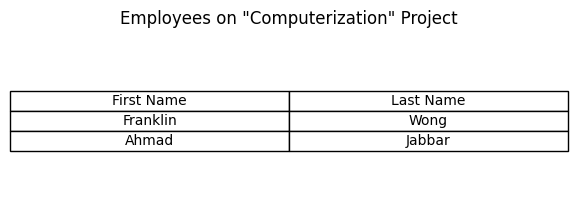

In [6]:
df1 = pd.DataFrame(results_1_1, columns=['First Name', 'Last Name'])

if not df1.empty:
    fig, ax = plt.subplots(figsize=(6, len(df1)*0.4 + 1))
    ax.axis('tight')
    ax.axis('off')

    # Create the table
    table = ax.table(cellText=df1.values,
                     colLabels=df1.columns,
                     cellLoc='center',
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    ax.set_title('Employees on "Computerization" Project', pad=20)

    plt.show()
else:
    print("No data for CONSULTA 01 to visualize.")
    conn.close()

In [7]:
"""Já a segunda query irá retornas nomes dos dependentes, vinculados a funcionários e que tem o sobrenome 'Smith'."""

"Já a segunda query irá retornas nomes dos dependentes, vinculados a funcionários e que tem o sobrenome 'Smith'."

In [8]:
c2 = conn.execute('''
SELECT D.Dependent_name
FROM DEPENDENT AS D
    INNER JOIN EMPLOYEE AS E 
        ON E.ssn = D.Essn AND E.Lname = 'Smith'
''')
print("Resultado CONSULTA 02")
results_1_2 = c2.fetchall()
print(results_1_2)
print("-------")
print('\n')

Resultado CONSULTA 02
[('Alice',), ('Joy',), ('Theodore',)]
-------




Resultado CONSULTA 02 (DataFrame):
  Dependent Name
0          Alice
1            Joy
2       Theodore
-------




/tmp/ipykernel_153776/1752468498.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Dependent Name', data=df2, palette='viridis', legend = False)


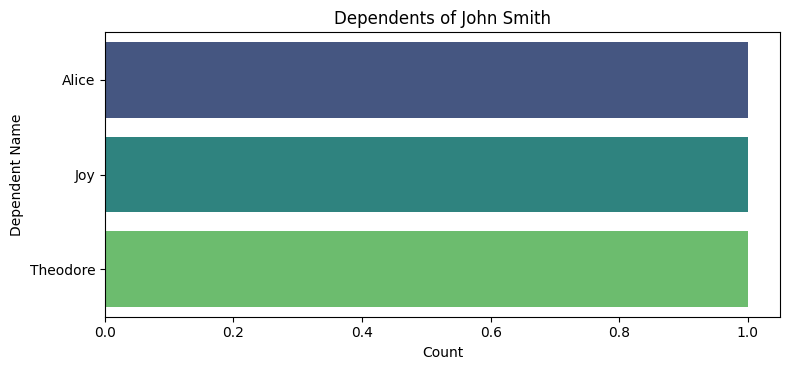

In [9]:
df2 = pd.DataFrame(results_1_2, columns=['Dependent Name'])

print("Resultado CONSULTA 02 (DataFrame):")
print(df2)
print("-------")
print('\n')

if not df2.empty:
    plt.figure(figsize=(8, len(df2)*0.6 + 2))

    sns.countplot(y='Dependent Name', data=df2, palette='viridis', legend = False)

    plt.title('Dependents of John Smith')
    plt.xlabel('Count')
    plt.ylabel('Dependent Name')
    plt.tight_layout()
    plt.show()

In [10]:
"""A terceira query irá conter o nome de cada departamento juntamente com a média salarial dos funcionários que pertencem a esse departamento."""

'A terceira query irá conter o nome de cada departamento juntamente com a média salarial dos funcionários que pertencem a esse departamento.'

In [11]:
c3 = conn.execute('''
SELECT D.Dname, AVG(E.Salary)
FROM DEPARTMENT AS D
    INNER JOIN EMPLOYEE AS E 
        ON D.Dnumber = E.Dno
GROUP BY D.Dname
''')
print("Resultado CONSULTA 03 (Raw Data):")
result_1_3 = c3.fetchall()
print(result_1_3)
print("-------")
print('\n')

Resultado CONSULTA 03 (Raw Data):
[('Administration', 34000.0), ('Headquarters', 59000.0), ('Research', 35000.0)]
-------




Resultado CONSULTA 03 (DataFrame):
  Department Name  Average Salary
0  Administration         34000.0
1    Headquarters         59000.0
2        Research         35000.0
-------




/tmp/ipykernel_153776/3851241185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department Name', y='Average Salary', data=df3, palette='coolwarm')


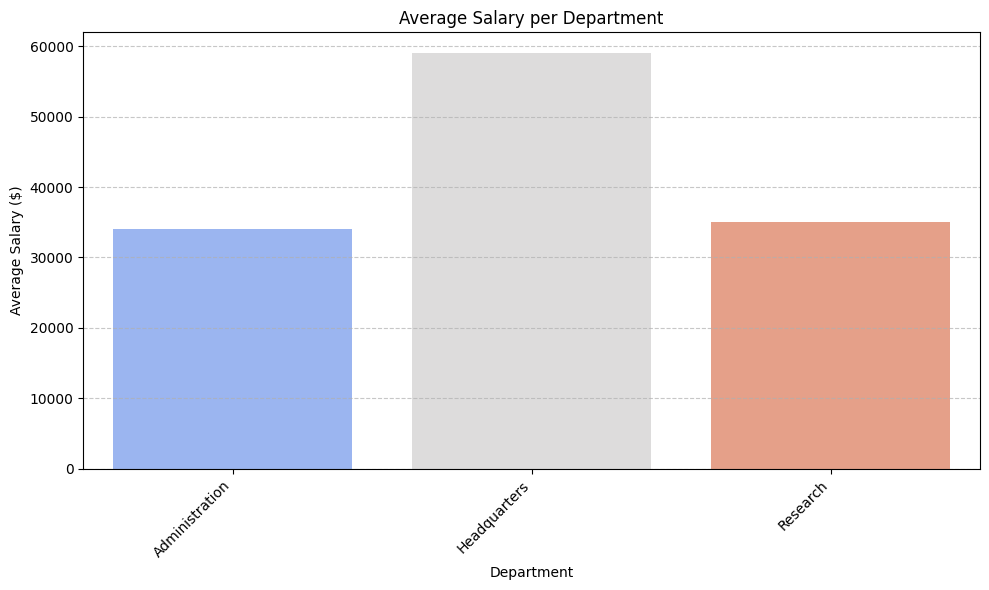

In [12]:
df3 = pd.DataFrame(result_1_3, columns=['Department Name', 'Average Salary'])

print("Resultado CONSULTA 03 (DataFrame):")
print(df3)
print("-------")
print('\n')

if not df3.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Department Name', y='Average Salary', data=df3, palette='coolwarm')
    plt.title('Average Salary per Department')
    plt.xlabel('Department')
    plt.ylabel('Average Salary ($)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data for CONSULTA 03 to visualize.")

In [13]:
""" A consuta 4 retornará o número de cada projeto e a contagem de funcionários que trabalham nesses projetos."""

' A consuta 4 retornará o número de cada projeto e a contagem de funcionários que trabalham nesses projetos.'

In [14]:
c4 = conn.execute('''
SELECT P.Pnumber, COUNT(WO.Essn)
FROM PROJECT AS P
    INNER JOIN WORKS_ON AS WO
        ON P.Pnumber = WO.Pno
GROUP BY P.Pnumber
''')
print("Resultado CONSULTA 04 (Raw Data):")
results_1_4 = c4.fetchall()

print(results_1_4)
print("-------")
print('\n')


Resultado CONSULTA 04 (Raw Data):
[(1, 2), (2, 3), (3, 2), (10, 2), (20, 2), (30, 3)]
-------




Resultado CONSULTA 04 (DataFrame):
   Project Name  Number of Employees
0             1                    2
1             2                    3
2             3                    2
3            10                    2
4            20                    2
5            30                    3
-------




/tmp/ipykernel_153776/3679761376.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Project Name', y='Number of Employees', data=df4, palette='rocket')


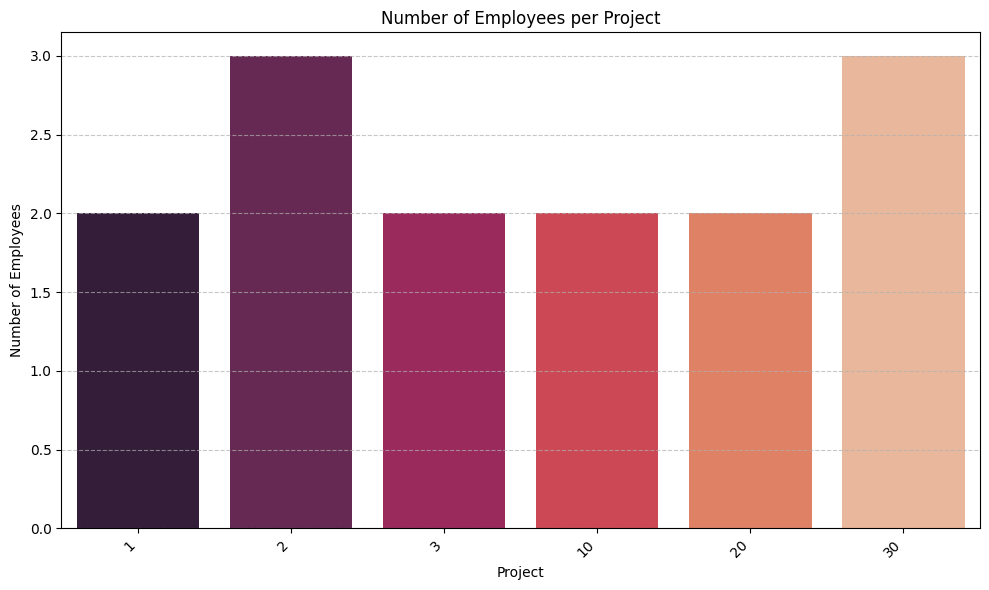

In [15]:
df4 = pd.DataFrame(results_1_4, columns=['Project Name', 'Number of Employees'])

print("Resultado CONSULTA 04 (DataFrame):")
print(df4)
print("-------")
print('\n')

if not df4.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Project Name', y='Number of Employees', data=df4, palette='rocket')
    plt.title('Number of Employees per Project')
    plt.xlabel('Project')
    plt.ylabel('Number of Employees')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data for CONSULTA 04 to visualize.")

In [16]:
""" A consulta retorna os nomes e sobrenomes dos funcionários que estão alocados em mais de um projeto."""

' A consulta retorna os nomes e sobrenomes dos funcionários que estão alocados em mais de um projeto.'

In [17]:
c5 = conn.execute('''
SELECT E.Fname, E.Lname
FROM EMPLOYEE AS E
    INNER JOIN WORKS_ON AS WO
        ON E.ssn = WO.Essn
GROUP BY E.ssn
HAVING COUNT(WO.Pno) > 1
''')
print("Resultado CONSULTA 05 (Raw Data):")
results_1_5 = c5.fetchall()
print(results_1_5)
print("-------")
print('\n')


Resultado CONSULTA 05 (Raw Data):
[('John', 'Smith'), ('Franklin', 'Wong'), ('Joyce', 'English'), ('Jennifer', 'Wallace'), ('Ahmad', 'Jabbar')]
-------




In [18]:
""" Como pode ser observado acima, os resultados das 5 consultas são diferentes porque cada consulta tem um propósito específico e retorna informações distintas do banco de dados."""

' Como pode ser observado acima, os resultados das 5 consultas são diferentes porque cada consulta tem um propósito específico e retorna informações distintas do banco de dados.'

## QUESTÃO 2

In [19]:
""" O resultado dessa primeira query da questão 2 irá retornar o número de cada departamento e o número de funcionários que trabalham nesse departamento que recebem um salário maior que 40.000."""

' O resultado dessa primeira query da questão 2 irá retornar o número de cada departamento e o número de funcionários que trabalham nesse departamento que recebem um salário maior que 40.000.'

In [20]:
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(*)
FROM DEPARTMENT AS D, EMPLOYEE AS E
WHERE D.Dnumber = E.Dno AND E.SALARY > 40000
GROUP BY D.Dnumber
''')
print("Resultado QUESTÃO 02")
print(q2_c1.fetchall())
print("-------")
print('\n')

Resultado QUESTÃO 02
[(1, 3), (4, 1), (5, 1)]
-------




In [ ]:
""" A query abaixo irá retornar o número de cada projeto e o número de funcionários que trabalham nesse projeto que recebem um salário maior que 40.000, MAS APENAS PARA OS PROJETOS QUE TEM MAIS DE 5 FUNCIONÁRIOS ALOCADOS."""

' A query abaixo irá retornar o número de cada projeto e o número de funcionários que trabalham nesse projeto que recebem um salário maior que 40.000, MAS APENAS PARA OS PROJETOS QUE TEM MAIS DE 5 FUNCIONÁRIOS ALLOCADOS.'

In [22]:
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(*)
FROM DEPARTMENT AS D, EMPLOYEE AS E
WHERE D.Dnumber = E.Dno AND E.SALARY > 40000 AND D.Dnumber IN (
                     SELECT E.Dno FROM EMPLOYEE AS E GROUP BY E.Dno HAVING COUNT(*) > 5)
GROUP BY D.Dnumber
''')
print("Resultado QUESTÃO 02")
results_q2_c1 = q2_c1.fetchall()
print(q2_c1.fetchall())
print("-------")
print('\n')

Resultado QUESTÃO 02
[]
-------




In [23]:
def insert_employee(conn, fname, minit, lname, ssn, bdate, address, sex, salary, super_ssn, dno):
    existing = conn.execute('SELECT 1 FROM EMPLOYEE WHERE Ssn = ?', (ssn,)).fetchone()
    if existing:
        print(f"Employee with SSN {ssn} already exists. Skipping insert.")
        return
    conn.execute('''
    INSERT INTO EMPLOYEE 
    (Fname, Minit, Lname, Ssn, Bdate, Address, Sex, Salary, Super_ssn, Dno)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?);
    ''', (fname, minit, lname, ssn, bdate, address, sex, salary, super_ssn, dno))
    conn.commit()
    print(f"Employee {fname} {lname} added successfully to Department {dno}.")


In [24]:
def populate_research(conn):
    insert_employee(conn, 'John', 'K', 'Smith', '123456789', '1985-01-09', '123 Houston St', 'M', 30000, '333445555', 5)
    insert_employee(conn, 'Alicia', 'J', 'Zelaya', '999887777', '1988-07-19', '456 Bellaire St', 'F', 25000, '333445555', 5)
    insert_employee(conn, 'Ramesh', 'K', 'Narayan', '666884444', '1990-09-15', '789 Richmond Ave', 'M', 38000, '333445555', 5)

In [25]:
def populate_administration(conn):
    insert_employee(conn, 'Joyce', 'A', 'English', '453453453', '1992-03-15', '321 Westheimer Rd', 'F', 25000, '987654321', 4)
    insert_employee(conn, 'Ahmad', 'V', 'Jabbar', '987987987', '1989-11-29', '654 Galleria Dr', 'M', 28000, '987654321', 4)


In [26]:
def populate_headquarters(conn):
    insert_employee(conn, 'Adam', 'S', 'Stone', '112233445', '1975-08-09', '700 Main St', 'M', 60000, '888665555', 1)
    insert_employee(conn, 'Eve', 'L', 'Green', '556677889', '1980-02-20', '701 Main St', 'F', 62000, '888665555', 1)
    insert_employee(conn, 'Noah', 'T', 'Brown', '998877665', '1982-05-30', '702 Main St', 'M', 58000, '888665555', 1)
    insert_employee(conn, 'Olivia', 'R', 'White', '334455667', '1995-12-25', '703 Main St', 'F', 54000, '888665555', 1)
    insert_employee(conn, 'Liam', 'M', 'Johnson', '223344556', '1990-10-10', '704 Main St', 'M', 50000, '888665555', 1)
    


In [27]:
def populate_managers(conn):
    insert_employee(conn, 'Franklin', 'T', 'Wong', '333445555', '1965-12-08', '638 Voss Rd', 'M', 40000, '888665555', 5)
    insert_employee(conn, 'Jennifer', 'S', 'Wallace', '987654321', '1970-06-20', '230 Bellaire St', 'F', 43000, '888665555', 4)
    insert_employee(conn, 'James', 'E', 'Borg', '888665555', '1955-11-10', '500 Main St', 'M', 55000, None, 1)

In [ ]:
def populate_all_employees(conn):
    populate_managers(conn)
    populate_research(conn)
    populate_administration(conn)
    populate_headquarters(conn)


In [29]:
populate_all_employees(conn)

Employee with SSN 333445555 already exists. Skipping insert.
Employee with SSN 987654321 already exists. Skipping insert.
Employee with SSN 888665555 already exists. Skipping insert.
Employee with SSN 123456789 already exists. Skipping insert.
Employee with SSN 999887777 already exists. Skipping insert.
Employee with SSN 666884444 already exists. Skipping insert.
Employee with SSN 453453453 already exists. Skipping insert.
Employee with SSN 987987987 already exists. Skipping insert.
Employee with SSN 112233445 already exists. Skipping insert.
Employee with SSN 556677889 already exists. Skipping insert.
Employee Noah Brown added successfully to Department 1.
Employee Olivia White added successfully to Department 1.
Employee Liam Johnson added successfully to Department 1.


In [ ]:
q2_c1 = conn.execute('''
SELECT D.Dnumber, COUNT(E.Ssn) AS HighEarners
FROM DEPARTMENT AS D
    INNER JOIN EMPLOYEE AS E
        ON D.Dnumber = E.Dno
WHERE E.SALARY > 40000
  AND D.Dnumber IN (SELECT Dno FROM EMPLOYEE GROUP BY Dno HAVING COUNT(*) > 5)
GROUP BY D.Dname
''')
print("Resultado QUESTÃO 02")
results_q2_c1 = q2_c1.fetchall()
print(results_q2_c1)
print("-------")
print('\n')

Resultado QUESTÃO 02
[(1, 6), (5, 1)]
-------




In [40]:
""" Como pode ser visto acima, para que a query não retorne um valor nulo, foi necessário alocar mais funcionários em cada departamento, de modo que o número de funcionários alocados em cada departamento fosse maior que 5."""

' Como pode ser visto acima, para que a query não retorne um valor nulo, foi necessário alocar mais funcionários em cada departamento, de modo que o número de funcionários alocados em cada departamento fosse maior que 5.'

In [41]:
def get_employees_by_department(conn, department_number):
    cursor = conn.execute('SELECT * FROM EMPLOYEE WHERE Dno = ?', (department_number,))
    columns = [desc[0] for desc in cursor.description]
    employees = []
    for row in cursor.fetchall():
        employees.append(dict(zip(columns, row)))
    return employees

In [43]:
""" O departamento 1 contém 6 funcionários que tem o salário que 5000, e podem ser vistos abaixo."""

' O departamento 1 contém 6 funcionários que tem o salário que 5000, e podem ser vistos abaixo.'

In [44]:
employees_in_dept_1 = get_employees_by_department(conn, 1)
for emp in employees_in_dept_1:
    print(emp)

{'Fname': 'James', 'Minit': 'E', 'Lname': 'Borg', 'Ssn': '888665555', 'Bdate': '1937-11-10', 'Address': '450 Stone, Houston, TX', 'Sex': 'M', 'Salary': 55000, 'Super_ssn': None, 'Dno': 1}
{'Fname': 'Adam', 'Minit': 'S', 'Lname': 'Stone', 'Ssn': '112233445', 'Bdate': '1975-08-09', 'Address': '700 Main St', 'Sex': 'M', 'Salary': 60000, 'Super_ssn': '888665555', 'Dno': 1}
{'Fname': 'Eve', 'Minit': 'L', 'Lname': 'Green', 'Ssn': '556677889', 'Bdate': '1980-02-20', 'Address': '701 Main St', 'Sex': 'F', 'Salary': 62000, 'Super_ssn': '888665555', 'Dno': 1}
{'Fname': 'Noah', 'Minit': 'T', 'Lname': 'Brown', 'Ssn': '998877665', 'Bdate': '1982-05-30', 'Address': '702 Main St', 'Sex': 'M', 'Salary': 58000, 'Super_ssn': '888665555', 'Dno': 1}
{'Fname': 'Olivia', 'Minit': 'R', 'Lname': 'White', 'Ssn': '334455667', 'Bdate': '1995-12-25', 'Address': '703 Main St', 'Sex': 'F', 'Salary': 54000, 'Super_ssn': '888665555', 'Dno': 1}
{'Fname': 'Liam', 'Minit': 'M', 'Lname': 'Johnson', 'Ssn': '223344556', 'Bd

In [45]:
""" Já o departamento 5 contém 5 funcionários que tem o salário que 5000, e podem ser vistos abaixo."""

' Já o departamento 5 contém 5 funcionários que tem o salário que 5000, e podem ser vistos abaixo.'

In [ ]:
employees_in_dept_1 = get_employees_by_department(conn, 5)
for emp in employees_in_dept_1:
    print(emp)  

{'Fname': 'Franklin', 'Minit': 'T', 'Lname': 'Wong', 'Ssn': '333445555', 'Bdate': '1955-12-08', 'Address': '638 Voss, Houston, TX', 'Sex': 'M', 'Salary': 40000, 'Super_ssn': '888665555', 'Dno': 5}
{'Fname': 'John', 'Minit': 'B', 'Lname': 'Smith', 'Ssn': '123456789', 'Bdate': '1965-01-09', 'Address': '731 Fondren, Houston, TX', 'Sex': 'M', 'Salary': 30000, 'Super_ssn': '333445555', 'Dno': 5}
{'Fname': 'Ramesh', 'Minit': 'K', 'Lname': 'Narayan', 'Ssn': '666884444', 'Bdate': '1962-09-15', 'Address': '975 Fire Oak, Humble, TX', 'Sex': 'M', 'Salary': 38000, 'Super_ssn': '333445555', 'Dno': 5}
{'Fname': 'Joyce', 'Minit': 'A', 'Lname': 'English', 'Ssn': '453453453', 'Bdate': '1972-07-31', 'Address': '5631 Rice, Houston, TX', 'Sex': 'F', 'Salary': 25000, 'Super_ssn': '333445555', 'Dno': 5}
{'Fname': 'Ahmad', 'Minit': 'V', 'Lname': 'Jabbar', 'Ssn': '987987987', 'Bdate': '1969-03-29', 'Address': '980 Dallas, Houston, TX', 'Sex': 'M', 'Salary': 25000, 'Super_ssn': '333445555', 'Dno': 5}
{'Fname':

## QUESTÃO 3

In [48]:
""" Para criar as retrições de integridade, devemos alterar diretamente o banco de dados, adicionando as restrições desejadas. Abaixo estão os comandos SQL para adicionar as restrições de integridade referencial."""

' Para criar as retrições de integridade, devemos alterar diretamente o banco de dados, adicionando as restrições desejadas. Abaixo estão os comandos SQL para adicionar as restrições de integridade referencial.'

In [50]:
""" A tabela abaixo, mostra a criação da tabela EMPLOYEE, sem as restrições de integridade referencial."""

' A tabela abaixo, mostra a criação da tabela EMPLOYEE, sem as restrições de integridade referencial.'

In [51]:
"""CREATE TABLE IF NOT EXISTS EMPLOYEE (
        Fname VARCHAR(30) NOT NULL,
        Minit CHAR(1),
        Lname VARCHAR(30) NOT NULL,
        Ssn CHAR(9) PRIMARY KEY,
        Bdate DATE,
        Address VARCHAR(100),
        Sex CHAR(1),
        Salary DECIMAL(10, 2),
        Super_ssn CHAR(9),
        Dno INT,
        FOREIGN KEY (Super_ssn) REFERENCES EMPLOYEE(Ssn),
        FOREIGN KEY (Dno) REFERENCES DEPARTMENT(Dnumber)
    );"""

'CREATE TABLE IF NOT EXISTS EMPLOYEE (\n        Fname VARCHAR(30) NOT NULL,\n        Minit CHAR(1),\n        Lname VARCHAR(30) NOT NULL,\n        Ssn CHAR(9) PRIMARY KEY,\n        Bdate DATE,\n        Address VARCHAR(100),\n        Sex CHAR(1),\n        Salary DECIMAL(10, 2),\n        Super_ssn CHAR(9),\n        Dno INT,\n        FOREIGN KEY (Super_ssn) REFERENCES EMPLOYEE(Ssn),\n        FOREIGN KEY (Dno) REFERENCES DEPARTMENT(Dnumber)\n    );'

In [ ]:
""" Já a tabela abaixo, mostra a criação da tabela EMPLOYEE, com as restrições de integridade referencial."""

In [ ]:
"""CREATE TABLE IF NOT EXISTS EMPLOYEE (
    Fname VARCHAR(30) NOT NULL,
    Minit CHAR(1),
    Lname VARCHAR(30) NOT NULL,
    Ssn CHAR(9) PRIMARY KEY,
    Bdate DATE NOT NULL,
    Address VARCHAR(100) NOT NULL,
    Sex CHAR(1) CHECK (Sex IN ('M', 'F')),
    Salary DECIMAL(10, 2) CHECK (Salary > 0),
    Super_ssn CHAR(9),
    Dno INT NOT NULL,
    FOREIGN KEY (Super_ssn) REFERENCES EMPLOYEE(Ssn) ON DELETE SET NULL ON UPDATE CASCADE,
    FOREIGN KEY (Dno) REFERENCES DEPARTMENT(Dnumber) ON DELETE RESTRICT ON UPDATE CASCADE
);
"""

In [53]:
""" Como pode ser visto, agora a tabela EMPLOYEE possui as restrições de integridade referencial, na criação do Bdate, Address, Sex, Salary, Super_ssn e Dno."""

' Como pode ser visto, agora a tabela EMPLOYEE possui as restrições de integridade referencial, na criação do Bdate, Address, Sex, Salary, Super_ssn e Dno.'

## QUESTÃO 4

In [54]:
""" A última etapa do exercício consiste em criar duas visões do meu banco de dados."""

' A última etapa do exercício consiste em criar duas visões do meu banco de dados.'

In [60]:
""" A primeira view consiste em pegar o nome e o sobrenome dos funcionários alocados na tabela EMPLOYEE. Enquanto a segunda consiste em pegar o nome e o número do departamento dos funcionários que estão em algum projeto."""

' A primeira view consiste em pegar o nome e o sobrenome dos funcionários alocados na tabela EMPLOYEE. Enquanto a segunda consiste em pegar o nome e o número do departamento dos funcionários que estão em algum projeto.'

In [64]:
def create_simple_views(conn):
    cursor = conn.cursor()

    cursor.execute('''
    CREATE VIEW IF NOT EXISTS Simple_Employee_Names AS
    SELECT Fname, Lname FROM EMPLOYEE;
    ''')

    cursor.execute('''
    CREATE VIEW IF NOT EXISTS Simple_Projects AS
    SELECT Pname, Dnum FROM PROJECT;
    ''')

    conn.commit()
create_simple_views(conn)

In [65]:
def check_views(conn):
    cursor = conn.cursor()

    # Check Simple_Employee_Names view
    cursor.execute("SELECT * FROM Simple_Employee_Names;")
    employees = cursor.fetchall()
    print("Simple_Employee_Names:")
    for row in employees:
        print(row)

    # Check Simple_Projects view
    cursor.execute("SELECT * FROM Simple_Projects;")
    projects = cursor.fetchall()
    print("\nSimple_Projects:")
    for row in projects:
        print(row)
check_views(conn)

Simple_Employee_Names:
('James', 'Borg')
('Franklin', 'Wong')
('John', 'Smith')
('Jennifer', 'Wallace')
('Alicia', 'Zelaya')
('Ramesh', 'Narayan')
('Joyce', 'English')
('Ahmad', 'Jabbar')
('Sarah', 'Connor')
('Adam', 'Stone')
('Eve', 'Green')
('Noah', 'Brown')
('Olivia', 'White')
('Liam', 'Johnson')

Simple_Projects:
('ProductX', 5)
('ProductY', 5)
('ProductZ', 5)
('Computerization', 4)
('Reorganization', 1)
('Newbenefits', 4)


In [ ]:
conn.close()